# Heuristics in Mixed-Integer Programming (MIP)

This notebook gives an intuitive and pedagogical introduction to some of the most important MIP heuristics:

- Feasibility Pump
- Feasibility Jump
- Local Search
- Local Branching
- RENS
- RINS

The focus here is on **intuition + geometry + small code examples + visualizations**.

---
## Learning goals

By the end of this notebook, you should be able to:

1. Explain why MIP heuristics are useful.
2. Understand how each heuristic constructs or improves feasible solutions.
3. Visualize neighborhoods and restricted searches.
4. Relate these heuristics to branch-and-bound / branch-and-cut.
5. Implement toy versions in Python.

## 1. Why heuristics matter in MIP

A generic MIP can be written as

\[
\begin{aligned}
\min \quad & c^\top x \\
\text{s.t.}\quad & Ax \le b, \\
& x_i \in \mathbb{Z} \quad \text{for } i \in I, \\
& x_j \in \mathbb{R} \quad \text{for } j \notin I.
\end{aligned}
\]

Exact methods such as branch-and-bound and branch-and-cut can prove optimality, but this can take a long time.

Heuristics are important because they help us:

- find an incumbent quickly,
- improve primal bounds,
- prune more of the search tree,
- guide subsequent exact search.

In practice, modern solvers use many heuristics throughout the solve.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle
from collections import deque

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

## 2. Taxonomy of heuristics

A useful classification is:

- **Rounding-based:** Feasibility Pump
- **Penalty / repair based:** Feasibility Jump
- **Neighborhood search:** Local Search, Local Branching
- **Relaxation-induced:** RENS, RINS

We will study each one with a small example.

## 3. A tiny binary MIP example

To keep the examples visual, let us consider a very small binary optimization problem:

\[
\begin{aligned}
\min \quad & -6x_1 - 5x_2 - 4x_3 \\
\text{s.t.}\quad & 3x_1 + 2x_2 + x_3 \le 4, \\
& x_1, x_2, x_3 \in \{0,1\}.
\end{aligned}
\]

Since the objective is negative, minimizing it is equivalent to preferring solutions with larger value.

In [2]:
weights = np.array([3, 2, 1])
profits = np.array([6, 5, 4])

all_points = []
for x1 in [0, 1]:
    for x2 in [0, 1]:
        for x3 in [0, 1]:
            x = np.array([x1, x2, x3], dtype=int)
            feasible = (weights @ x) <= 4
            obj = -(profits @ x)
            all_points.append((x, feasible, obj))

feasible_points = [p for p in all_points if p[1]]
best = min(feasible_points, key=lambda t: t[2])

print("All binary points:")
for x, feas, obj in all_points:
    print(f"x={x}, feasible={feas}, objective={obj}")

print("\nBest feasible solution:")
print(best)

All binary points:
x=[0 0 0], feasible=True, objective=0
x=[0 0 1], feasible=True, objective=-4
x=[0 1 0], feasible=True, objective=-5
x=[0 1 1], feasible=True, objective=-9
x=[1 0 0], feasible=True, objective=-6
x=[1 0 1], feasible=True, objective=-10
x=[1 1 0], feasible=False, objective=-11
x=[1 1 1], feasible=False, objective=-15

Best feasible solution:
(array([1, 0, 1]), np.True_, np.int64(-10))


## 4. Visualizing the solution space as a graph

For binary variables, each feasible solution can be seen as a node in a hypercube.  
Two solutions are neighbors if they differ in one bit (Hamming distance \(1\)).

This is a natural view for local search heuristics.

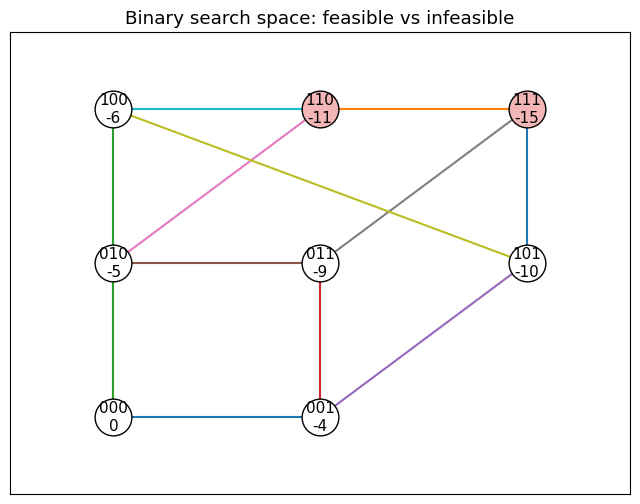

In [3]:
def hamming(a, b):
    return int(np.sum(np.abs(a - b)))

points = [p[0] for p in all_points]
labels = [''.join(map(str, p)) for p in points]
coords = {
    '000': (0, 0),
    '001': (1, 0),
    '010': (0, 1),
    '100': (0, 2),
    '011': (1, 1),
    '101': (2, 1),
    '110': (1, 2),
    '111': (2, 2),
}

fig, ax = plt.subplots(figsize=(8, 6))

for i, p in enumerate(points):
    for j, q in enumerate(points):
        if j > i and hamming(p, q) == 1:
            pi, pj = ''.join(map(str, p)), ''.join(map(str, q))
            xi, yi = coords[pi]
            xj, yj = coords[pj]
            ax.plot([xi, xj], [yi, yj], linewidth=1.5)

for x, feasible, obj in all_points:
    key = ''.join(map(str, x))
    px, py = coords[key]
    face = "white" if feasible else "#f2b6b6"
    edge = "black"
    ax.scatter(px, py, s=700, color=face, edgecolor=edge, zorder=3)
    ax.text(px, py, f"{key}\n{obj}", ha="center", va="center")

ax.set_title("Binary search space: feasible vs infeasible")
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlim(-0.5, 2.5)
ax.set_ylim(-0.5, 2.5)
plt.show()

Interpretation:

- White nodes are feasible.
- Red nodes are infeasible.
- Edges represent one-bit moves.

This picture is the mental model behind many primal heuristics.

## 5. Feasibility Pump

### 5.1 Core idea

Feasibility Pump alternates between:

1. solving a continuous relaxation,
2. rounding the fractional point to an integer point,
3. projecting / re-optimizing toward feasibility.

Very roughly, it tries to reconcile two goals:

- be close to the LP solution,
- be integer and feasible.

### 5.2 Schematic view

Let \(x^{LP}\) be the fractional relaxation solution, and let \(x^I\) be its rounded version.

Then the method tries to solve subproblems of the form

\[
\min \|x - x^I\|_1
\quad \text{s.t. } Ax \le b.
\]

If \(x^I\) is feasible, we are done.

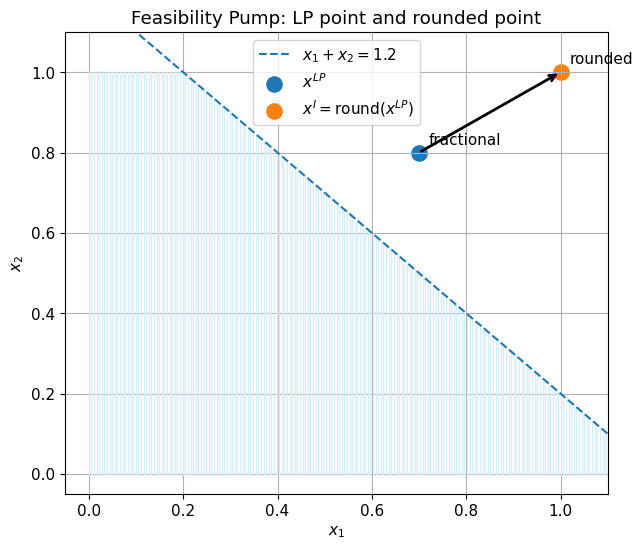

In [4]:
# simple geometric picture in 2D
x_lp = np.array([0.7, 0.8])
x_round = np.round(x_lp)

fig, ax = plt.subplots(figsize=(7, 6))

# feasible region: x1 + x2 <= 1.2, 0<=x<=1
grid = np.linspace(0, 1.1, 200)
for x in grid:
    y = min(1.2 - x, 1.0)
    if y >= 0:
        ax.plot([x, x], [0, y], color="#d9edf7", linewidth=1)

ax.plot([0, 1.2], [1.2, 0], linestyle="--", linewidth=1.5, label=r"$x_1 + x_2 = 1.2$")
ax.scatter(*x_lp, s=120, label=r"$x^{LP}$")
ax.scatter(*x_round, s=120, label=r"$x^I = \mathrm{round}(x^{LP})$")
ax.annotate("", xy=x_round, xytext=x_lp, arrowprops=dict(arrowstyle="->", lw=2))
ax.text(x_lp[0]+0.02, x_lp[1]+0.02, "fractional")
ax.text(x_round[0]+0.02, x_round[1]+0.02, "rounded")

ax.set_xlim(-0.05, 1.1)
ax.set_ylim(-0.05, 1.1)
ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.set_title("Feasibility Pump: LP point and rounded point")
ax.legend()
plt.show()

### 5.3 Toy Feasibility Pump code

The code below is intentionally simple. It does **not** implement a production-quality feasibility pump; it just illustrates the alternation logic.

In [5]:
def toy_feasibility_pump(lp_points, is_feasible, n_iter=10):
    history = []
    x_lp = np.array(lp_points[0], dtype=float)

    for k in range(n_iter):
        x_int = np.round(x_lp).astype(int)
        history.append((x_lp.copy(), x_int.copy(), is_feasible(x_int)))

        if is_feasible(x_int):
            return x_int, history

        # "projection" step: choose feasible LP-like point closest to x_int
        candidates = [np.array(p, dtype=float) for p in lp_points]
        x_lp = min(candidates, key=lambda p: np.sum(np.abs(p - x_int)))

    return None, history

lp_candidates = [
    [0.7, 0.8],
    [0.6, 0.5],
    [0.9, 0.2],
    [0.4, 0.6],
]

def feas2d(x):
    return (x[0] + x[1] <= 1.2) and np.all((x >= 0) & (x <= 1))

sol, hist = toy_feasibility_pump(lp_candidates, feas2d, n_iter=5)
print("Returned solution:", sol)
print("History:")
for k, (lp, xi, feas) in enumerate(hist):
    print(f"iter={k}, x_lp={lp}, x_int={xi}, feasible={feas}")

Returned solution: None
History:
iter=0, x_lp=[0.7 0.8], x_int=[1 1], feasible=False
iter=1, x_lp=[0.7 0.8], x_int=[1 1], feasible=False
iter=2, x_lp=[0.7 0.8], x_int=[1 1], feasible=False
iter=3, x_lp=[0.7 0.8], x_int=[1 1], feasible=False
iter=4, x_lp=[0.7 0.8], x_int=[1 1], feasible=False


## 6. Feasibility Jump

### 6.1 Core idea

Feasibility Jump works directly in the integer space.

Instead of repeatedly solving LPs, it evaluates integer moves using a score like

\[
\text{score}(x) = c^\top x + \lambda \cdot \text{violation}(x),
\]

where the violation term measures how much the constraints are broken.

Then it performs greedy or semi-greedy improving moves.

In [6]:
def violation(x):
    return max(0, weights @ x - 4)

def score(x, lam=20):
    return -(profits @ x) + lam * violation(x)

def neighbors_binary(x):
    nbs = []
    for i in range(len(x)):
        y = x.copy()
        y[i] = 1 - y[i]
        nbs.append(y)
    return nbs

x = np.array([1, 1, 1], dtype=int)  # infeasible start
path = [x.copy()]

for _ in range(10):
    nbs = neighbors_binary(x)
    best_nb = min(nbs, key=lambda y: score(y))
    if score(best_nb) < score(x):
        x = best_nb
        path.append(x.copy())
    else:
        break

print("Feasibility Jump path:")
for p in path:
    print(p, "score=", score(p), "violation=", violation(p))

Feasibility Jump path:
[1 1 1] score= 25 violation= 2
[1 0 1] score= -10 violation= 0


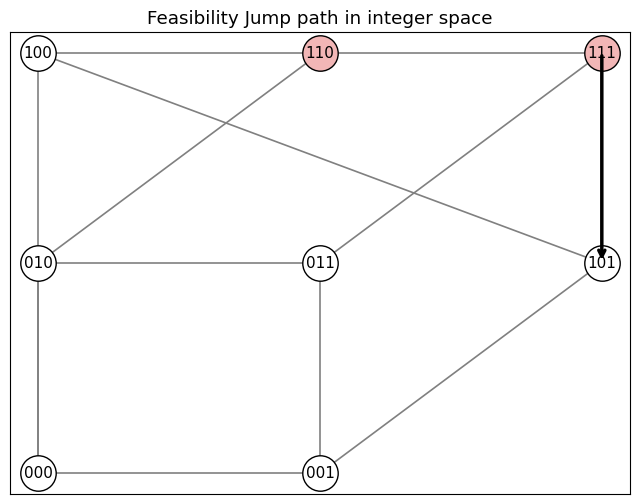

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

for i, p in enumerate(points):
    for j, q in enumerate(points):
        if j > i and hamming(p, q) == 1:
            pi, pj = ''.join(map(str, p)), ''.join(map(str, q))
            xi, yi = coords[pi]
            xj, yj = coords[pj]
            ax.plot([xi, xj], [yi, yj], linewidth=1.2, color="gray")

for x0, feasible, obj in all_points:
    key = ''.join(map(str, x0))
    px, py = coords[key]
    face = "white" if feasible else "#f2b6b6"
    ax.scatter(px, py, s=650, color=face, edgecolor="black", zorder=3)
    ax.text(px, py, key, ha="center", va="center")

for a, b in zip(path[:-1], path[1:]):
    pa, pb = ''.join(map(str, a)), ''.join(map(str, b))
    xa, ya = coords[pa]
    xb, yb = coords[pb]
    ax.annotate("", xy=(xb, yb), xytext=(xa, ya),
                arrowprops=dict(arrowstyle="->", lw=2.5))

ax.set_title("Feasibility Jump path in integer space")
ax.set_xticks([])
ax.set_yticks([])
plt.show()

This picture shows the main difference from feasibility pump:

- Feasibility Pump alternates between continuous and integer worlds.
- Feasibility Jump stays in the integer world and repairs infeasibility via local moves.

## 7. Local Search

### 7.1 Core idea

Local search starts from a feasible solution and explores nearby feasible solutions.

A natural neighborhood for binary vectors is

\[
\mathcal{N}(x) = \{y : d_H(x,y) \le k\},
\]

where \(d_H\) is Hamming distance.

For \(k=1\), the search only flips one bit at a time.

In [8]:
start = np.array([1, 0, 1], dtype=int)

def feasible_neighbors(x):
    return [y for y in neighbors_binary(x) if (weights @ y) <= 4]

improvement_path = [start.copy()]
x = start.copy()

for _ in range(10):
    nbs = feasible_neighbors(x)
    best_nb = min(nbs, key=lambda y: -(profits @ y))
    if -(profits @ best_nb) < -(profits @ x):
        x = best_nb
        improvement_path.append(x.copy())
    else:
        break

print("Local search path:")
for p in improvement_path:
    print(p, "objective=", -(profits @ p))

Local search path:
[1 0 1] objective= -10


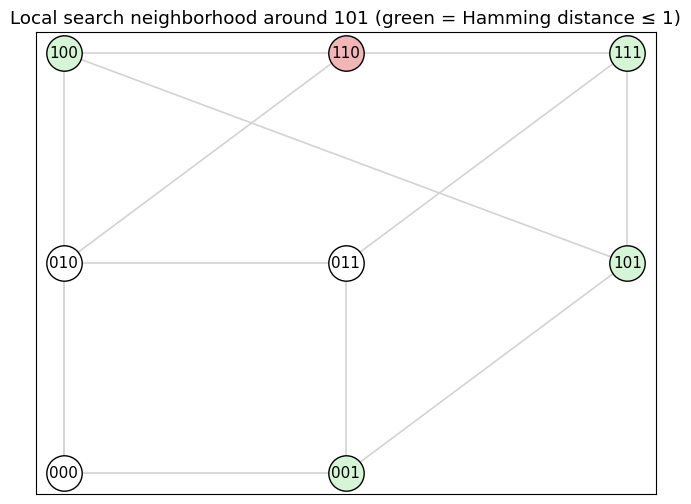

In [9]:
center = start
fig, ax = plt.subplots(figsize=(8, 6))

for i, p in enumerate(points):
    for j, q in enumerate(points):
        if j > i and hamming(p, q) == 1:
            pi, pj = ''.join(map(str, p)), ''.join(map(str, q))
            xi, yi = coords[pi]
            xj, yj = coords[pj]
            ax.plot([xi, xj], [yi, yj], linewidth=1.2, color="lightgray")

for x0, feasible, obj in all_points:
    key = ''.join(map(str, x0))
    px, py = coords[key]
    dist = hamming(x0, center)
    face = "#d6f5d6" if dist <= 1 else ("white" if feasible else "#f2b6b6")
    ax.scatter(px, py, s=650, color=face, edgecolor="black", zorder=3)
    ax.text(px, py, key, ha="center", va="center")

ax.set_title("Local search neighborhood around 101 (green = Hamming distance ≤ 1)")
ax.set_xticks([])
ax.set_yticks([])
plt.show()

The green nodes are the 1-flip neighborhood around the incumbent \(x^* = (1,0,1)\).
A local search heuristic explores such neighborhoods looking for an improving move.

## 8. Local Branching

### 8.1 Core idea

Local Branching transforms a neighborhood search into a restricted MIP by adding a constraint around the incumbent \(x^*\).

For binary variables, the classic local branching cut is

\[
\sum_{i : x_i^*=1}(1-x_i) + \sum_{i : x_i^*=0} x_i \le k.
\]

This is exactly a Hamming-ball constraint:

\[
d_H(x, x^*) \le k.
\]

So local branching says: *solve the MIP, but only inside this neighborhood*.

In [10]:
def hamming_ball(center, k):
    inside = []
    outside = []
    for x, feas, obj in all_points:
        if hamming(x, center) <= k:
            inside.append((x, feas, obj))
        else:
            outside.append((x, feas, obj))
    return inside, outside

center = np.array([1, 0, 1], dtype=int)
inside, outside = hamming_ball(center, k=1)

print("Inside local branching neighborhood:")
for x, feas, obj in inside:
    print(x, "feasible=", feas, "objective=", obj)

Inside local branching neighborhood:
[0 0 1] feasible= True objective= -4
[1 0 0] feasible= True objective= -6
[1 0 1] feasible= True objective= -10
[1 1 1] feasible= False objective= -15


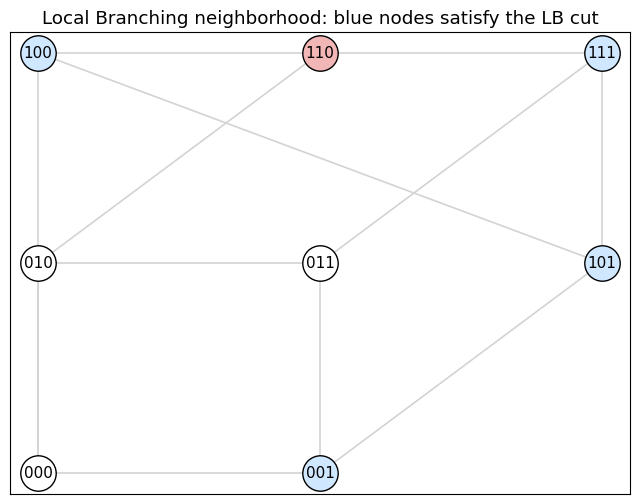

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))

for i, p in enumerate(points):
    for j, q in enumerate(points):
        if j > i and hamming(p, q) == 1:
            pi, pj = ''.join(map(str, p)), ''.join(map(str, q))
            xi, yi = coords[pi]
            xj, yj = coords[pj]
            ax.plot([xi, xj], [yi, yj], linewidth=1.2, color="lightgray")

for x0, feasible, obj in all_points:
    key = ''.join(map(str, x0))
    px, py = coords[key]
    in_ball = hamming(x0, center) <= 1
    face = "#cfe8ff" if in_ball else ("white" if feasible else "#f2b6b6")
    ax.scatter(px, py, s=650, color=face, edgecolor="black", zorder=3)
    ax.text(px, py, key, ha="center", va="center")

ax.set_title("Local Branching neighborhood: blue nodes satisfy the LB cut")
ax.set_xticks([])
ax.set_yticks([])
plt.show()

### 8.2 Why this is powerful

Unlike simple local search, local branching does **not** only inspect immediate neighbors.  
It gives a **restricted exact subproblem** to the solver.

So it mixes two worlds:

- heuristic intensification,
- exact optimization inside a neighborhood.

## 9. RENS

### 9.1 Core idea

RENS stands for **Relaxation Enforced Neighborhood Search**.

The basic logic is:

1. solve the LP relaxation,
2. fix variables that are already integral in the LP solution,
3. solve the reduced sub-MIP on the remaining fractional variables.

If a variable is already integral in the LP relaxation, it is considered stable enough to keep fixed.

In [12]:
x_lp = np.array([1.0, 0.35, 0.0, 0.8, 1.0, 0.0])

fixed = {}
free = []
for i, val in enumerate(x_lp):
    if abs(val - round(val)) < 1e-9:
        fixed[i] = int(round(val))
    else:
        free.append(i)

print("LP relaxation solution:", x_lp)
print("Fixed variables in RENS:", fixed)
print("Free variables in RENS:", free)

LP relaxation solution: [1.   0.35 0.   0.8  1.   0.  ]
Fixed variables in RENS: {0: 1, 2: 0, 4: 1, 5: 0}
Free variables in RENS: [1, 3]


Mathematically, if \(x^{LP}\) is the relaxation solution, RENS typically fixes

\[
x_i = x_i^{LP} \quad \text{for all integer } x_i^{LP}.
\]

Then the solver searches only over the variables that remain fractional.

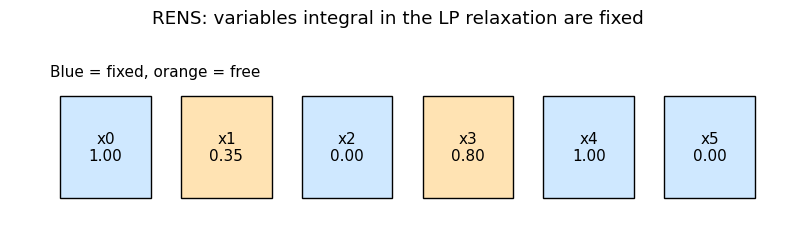

In [13]:
fig, ax = plt.subplots(figsize=(10, 2.5))

for i, val in enumerate(x_lp):
    x0 = 1.2 * i
    color = "#cfe8ff" if i in fixed else "#ffe3b3"
    rect = Rectangle((x0, 0.2), 0.9, 0.8, facecolor=color, edgecolor="black")
    ax.add_patch(rect)
    ax.text(x0 + 0.45, 0.6, f"x{i}\n{val:.2f}", ha="center", va="center")

ax.text(-0.1, 1.15, "Blue = fixed, orange = free", fontsize=11)
ax.set_xlim(-0.5, 1.2 * len(x_lp))
ax.set_ylim(0, 1.5)
ax.axis("off")
ax.set_title("RENS: variables integral in the LP relaxation are fixed")
plt.show()

## 10. RINS

### 10.1 Core idea

RINS stands for **Relaxation Induced Neighborhood Search**.

It combines:

- the current incumbent \(x^*\),
- the current LP solution \(x^{LP}\).

Variables are fixed where both solutions agree.

In [14]:
x_lp = np.array([1.0, 0.0, 0.42, 1.0, 0.3, 0.0])
x_star = np.array([1,   0,   1,    1,   0,   0])

fixed_rins = {}
free_rins = []

for i, (a, b) in enumerate(zip(x_lp, x_star)):
    if abs(a - b) < 1e-9:
        fixed_rins[i] = int(b)
    else:
        free_rins.append(i)

print("LP solution: ", x_lp)
print("Incumbent:   ", x_star)
print("Fixed in RINS:", fixed_rins)
print("Free in RINS:", free_rins)

LP solution:  [1.   0.   0.42 1.   0.3  0.  ]
Incumbent:    [1 0 1 1 0 0]
Fixed in RINS: {0: 1, 1: 0, 3: 1, 5: 0}
Free in RINS: [2, 4]


In symbolic form, the idea is

\[
x_i = x_i^* \quad \text{whenever } x_i^{LP} = x_i^*.
\]

This is often stronger than RENS because it uses both primal and relaxation information.

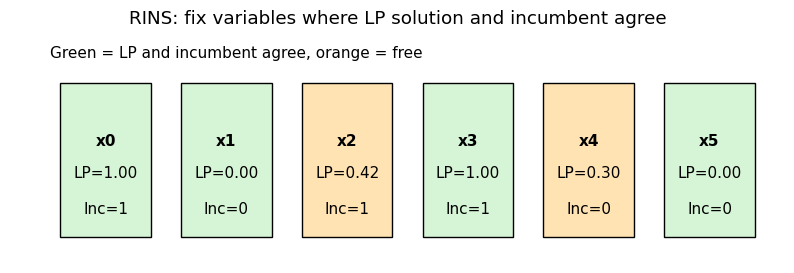

In [15]:
fig, ax = plt.subplots(figsize=(10, 3))

for i, (a, b) in enumerate(zip(x_lp, x_star)):
    x0 = 1.2 * i
    agree = abs(a - b) < 1e-9
    color = "#d6f5d6" if agree else "#ffe3b3"
    rect = Rectangle((x0, 0.2), 0.9, 1.2, facecolor=color, edgecolor="black")
    ax.add_patch(rect)
    ax.text(x0 + 0.45, 0.95, f"x{i}", ha="center", va="center", fontweight="bold")
    ax.text(x0 + 0.45, 0.7, f"LP={a:.2f}", ha="center", va="center")
    ax.text(x0 + 0.45, 0.42, f"Inc={b}", ha="center", va="center")

ax.text(-0.1, 1.6, "Green = LP and incumbent agree, orange = free", fontsize=11)
ax.set_xlim(-0.5, 1.2 * len(x_lp))
ax.set_ylim(0, 1.8)
ax.axis("off")
ax.set_title("RINS: fix variables where LP solution and incumbent agree")
plt.show()

## 11. Branch-and-bound tree view

Heuristics are not isolated tricks.  
They interact strongly with the branch-and-bound tree.

A good incumbent found early can dramatically reduce the tree because many nodes are pruned by bound.

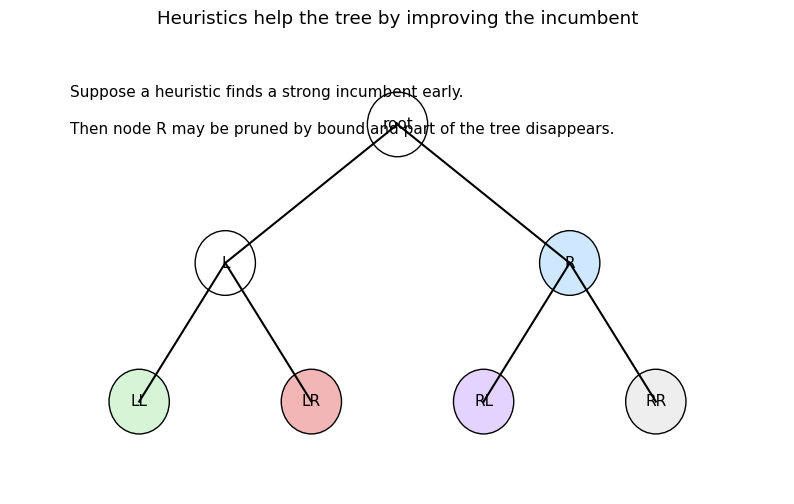

In [16]:
# simple manually drawn branch-and-bound tree
nodes = {
    "root": (0, 0),
    "L": (-2, -1.5),
    "R": (2, -1.5),
    "LL": (-3, -3),
    "LR": (-1, -3),
    "RL": (1, -3),
    "RR": (3, -3),
}

edges = [("root", "L"), ("root", "R"), ("L", "LL"), ("L", "LR"), ("R", "RL"), ("R", "RR")]

status = {
    "root": "open",
    "L": "open",
    "R": "pruned_by_bound",
    "LL": "integer",
    "LR": "pruned_by_infeas",
    "RL": "fathomed",
    "RR": "not_created",
}

colors = {
    "open": "white",
    "pruned_by_bound": "#cfe8ff",
    "pruned_by_infeas": "#f2b6b6",
    "integer": "#d6f5d6",
    "fathomed": "#e4d3ff",
    "not_created": "#eeeeee",
}

fig, ax = plt.subplots(figsize=(10, 6))

for a, b in edges:
    xa, ya = nodes[a]
    xb, yb = nodes[b]
    ax.plot([xa, xb], [ya, yb], color="black", linewidth=1.5)

for name, (x, y) in nodes.items():
    circle = Circle((x, y), 0.35, facecolor=colors[status[name]], edgecolor="black")
    ax.add_patch(circle)
    ax.text(x, y, name, ha="center", va="center")

ax.text(-3.8, 0.3, "Suppose a heuristic finds a strong incumbent early.", fontsize=11)
ax.text(-3.8, -0.1, "Then node R may be pruned by bound and part of the tree disappears.", fontsize=11)

ax.set_xlim(-4.5, 4.5)
ax.set_ylim(-4, 1)
ax.axis("off")
ax.set_title("Heuristics help the tree by improving the incumbent")
plt.show()

Interpretation:

- Green nodes correspond to integer feasible solutions.
- Blue nodes are pruned by bound.
- Red nodes are infeasible.
- Gray areas represent parts of the tree that may never need to be explored.

This is the main practical role of many primal heuristics:  
they improve the incumbent and therefore make exact search easier.

## 12. Gurobi-style code snippets

The following snippets are illustrative only. They show the logic, not a full solver implementation.

In [17]:
# Local Branching cut (binary case)
# sum_{i: x_i*=1} (1 - x_i) + sum_{i: x_i*=0} x_i <= k

import gurobipy as gp

def add_local_branching_cut(model, x, x_star, k):
    expr = gp.quicksum((1 - x[i]) if x_star[i] == 1 else x[i] for i in range(len(x_star)))
    model.addConstr(expr <= k, name="local_branching")

In [18]:
# RENS-style fixing
def rens_fixing(model, x, x_lp, tol=1e-9):
    for i, val in enumerate(x_lp):
        if abs(val - round(val)) <= tol:
            x[i].lb = int(round(val))
            x[i].ub = int(round(val))

In [19]:
# RINS-style fixing
def rins_fixing(model, x, x_lp, x_star, tol=1e-9):
    for i, (a, b) in enumerate(zip(x_lp, x_star)):
        if abs(a - b) <= tol:
            x[i].lb = int(b)
            x[i].ub = int(b)

## 13. Summary table

| Heuristic | Main idea | Search space | Typical use |
|---|---|---|---|
| Feasibility Pump | Alternate LP and rounding | Continuous + integer | Get a first feasible solution |
| Feasibility Jump | Penalized repair in integer space | Integer neighborhood | Repair infeasibility quickly |
| Local Search | Improve by nearby feasible moves | Small neighborhood | Incumbent improvement |
| Local Branching | Solve restricted MIP around incumbent | Exact inside neighborhood | Strong intensification |
| RENS | Fix LP-integral variables | Reduced sub-MIP | Exploit stable LP structure |
| RINS | Fix variables where LP and incumbent agree | Reduced sub-MIP | Exploit primal + LP agreement |

---
## 14. Exercises

1. Modify the local branching radius \(k\) and visualize the neighborhood growth.
2. Change the penalty parameter \(\lambda\) in feasibility jump and see how the path changes.
3. Extend the local search neighborhood from one-bit flips to two-bit flips.
4. Build a small knapsack instance and compare RENS and RINS fixings.
5. Use a real MIP solver and test these ideas on a tiny binary model.

---
## 15. Final remarks

The main message is:

- **heuristics are about structured shortcuts**, not arbitrary guesses;
- each heuristic exploits a different kind of information:
  - LP geometry,
  - incumbent structure,
  - local neighborhood topology,
  - repair dynamics.

That is why modern MIP solvers combine many of them instead of relying on only one.